In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import (
    bernoulli, binom, poisson,
    norm, uniform, lognorm, pareto
)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('Kütüphaneler yüklendi ✓')

Kütüphaneler yüklendi ✓


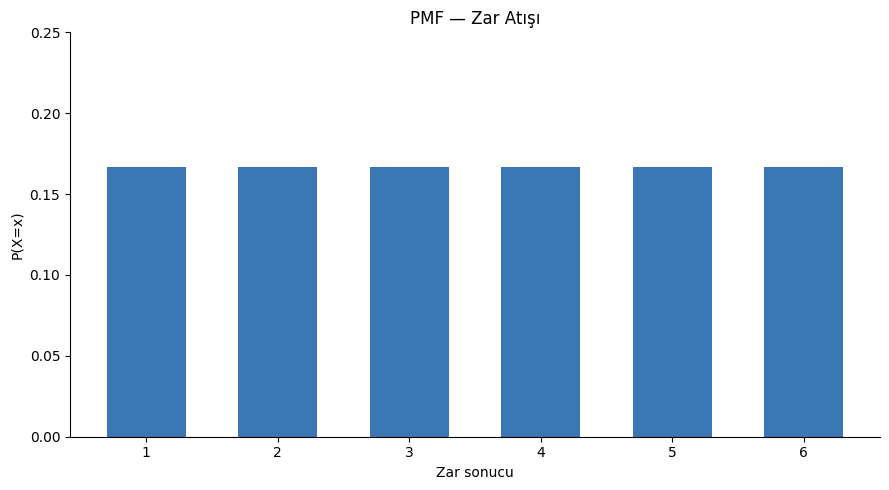

Toplam olasılık: 1.0  (her zaman 1 olmalı)


In [2]:
# Zar atışı — her değer eşit olasılıklı
x = np.arange(1, 7)
pmf = np.ones(6) / 6

plt.bar(x, pmf, color='#185FA5', alpha=0.85, width=0.6)
plt.xticks(x)
plt.xlabel('Zar sonucu')
plt.ylabel('P(X=x)')
plt.title('PMF — Zar Atışı')
plt.ylim(0, 0.25)
plt.tight_layout()
plt.show()

print(f'Toplam olasılık: {pmf.sum():.1f}  (her zaman 1 olmalı)')

## 2. PDF — Olasılık Yoğunluk Fonksiyonu (Sürekli)

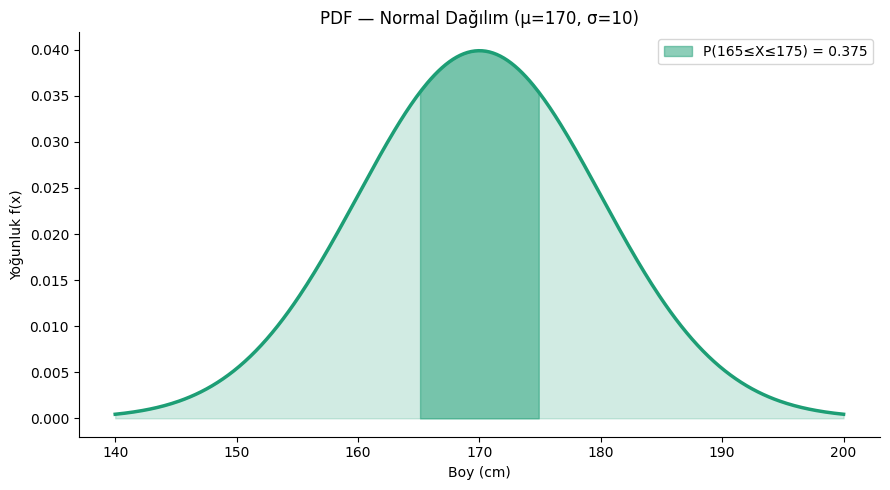

In [3]:
# İnsan boyu — normal dağılım
x = np.linspace(140, 200, 400)
y = norm.pdf(x, loc=170, scale=10)

plt.fill_between(x, y, alpha=0.2, color='#1D9E75')
plt.plot(x, y, color='#1D9E75', linewidth=2.5)

# 165-175 arası alan
mask = (x >= 165) & (x <= 175)
alan = np.trapz(y[mask], x[mask])
plt.fill_between(x[mask], y[mask], alpha=0.5, color='#1D9E75',
                 label=f'P(165≤X≤175) = {alan:.3f}')

plt.xlabel('Boy (cm)')
plt.ylabel('Yoğunluk f(x)')
plt.title('PDF — Normal Dağılım (μ=170, σ=10)')
plt.legend()
plt.tight_layout()
plt.show()

## 3. CDF — Kümülatif Dağılım Fonksiyonu

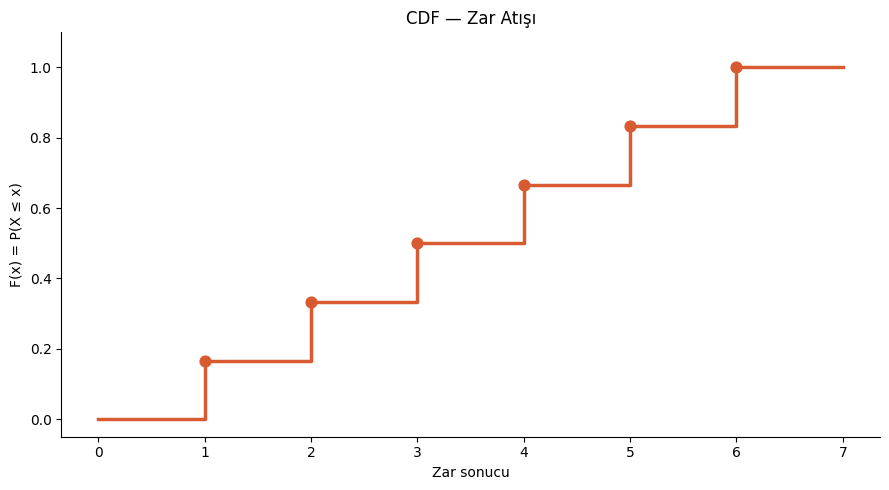

CDF özellikleri:
  - 0 dan başlar, 1 de biter
  - Monoton artar, hiç azalmaz


In [4]:
# Zar atışı CDF
x_zar = np.arange(0, 8)
cdf_zar = [0, 1/6, 2/6, 3/6, 4/6, 5/6, 1, 1]

plt.step(x_zar, cdf_zar, where='post', color='#D85A30', linewidth=2.5)
plt.scatter(np.arange(1,7), [i/6 for i in range(1,7)],
            color='#D85A30', s=60, zorder=5)
plt.xlabel('Zar sonucu')
plt.ylabel('F(x) = P(X ≤ x)')
plt.title('CDF — Zar Atışı')
plt.ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()

print('CDF özellikleri:')
print('  - 0 dan başlar, 1 de biter')
print('  - Monoton artar, hiç azalmaz')

## 4. Bernoulli Dağılımı

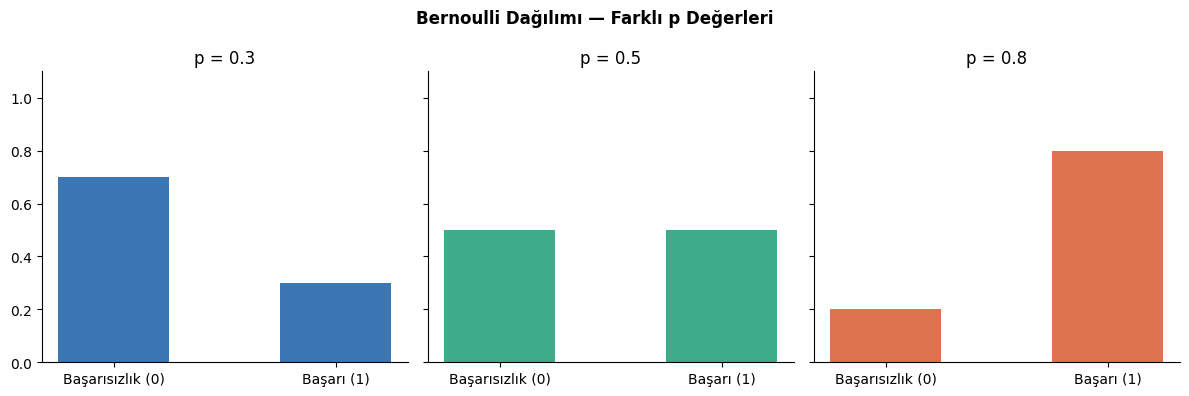

Müşteri satın alır  : 0.035 = %3.5000000000000004
Müşteri almaz       : 0.965 = %96.5


In [5]:
# Farklı p değerleri için Bernoulli
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
renkler = ['#185FA5', '#1D9E75', '#D85A30']

for ax, p, renk in zip(axes, [0.3, 0.5, 0.8], renkler):
    dist = bernoulli(p)
    ax.bar([0, 1], [dist.pmf(0), dist.pmf(1)], color=renk, alpha=0.85, width=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Başarısızlık (0)', 'Başarı (1)'])
    ax.set_title(f'p = {p}')
    ax.set_ylim(0, 1.1)

fig.suptitle('Bernoulli Dağılımı — Farklı p Değerleri', fontweight='bold')
plt.tight_layout()
plt.show()

# E-ticaret örneği
p_satin = 0.035  # %3.5 dönüşüm oranı
print(f'Müşteri satın alır  : {p_satin:.3f} = %{p_satin*100}')
print(f'Müşteri almaz       : {1-p_satin:.3f} = %{(1-p_satin)*100:.1f}')

## 5. Binom Dağılımı

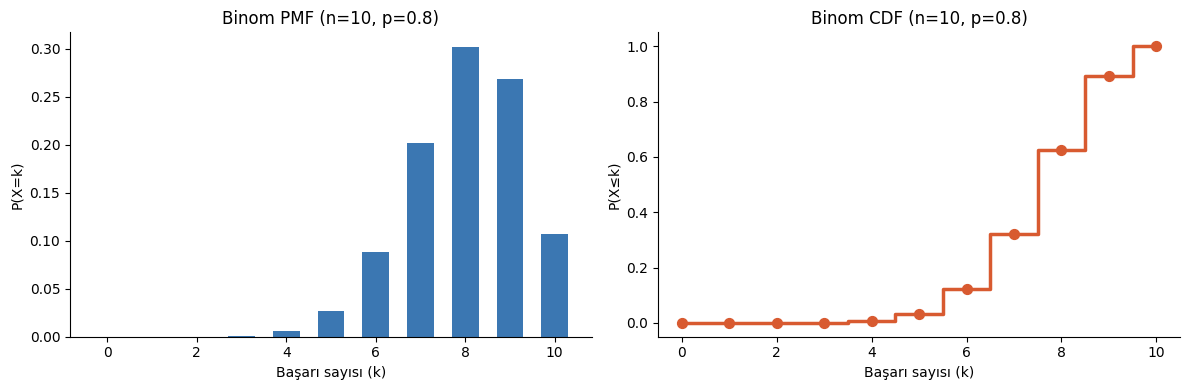

P(X=8)  = 0.3020  (tam 8 başarı)
P(X≤8)  = 0.6242  (en fazla 8 başarı)
Beklenen başarı = n×p = 8.0


In [6]:
# Basketbol örneği: n=10 atış, p=0.8
n, p = 10, 0.8
k = np.arange(0, 11)
pmf = binom.pmf(k, n, p)
cdf = binom.cdf(k, n, p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(k, pmf, color='#185FA5', alpha=0.85, width=0.6)
axes[0].set_xlabel('Başarı sayısı (k)')
axes[0].set_ylabel('P(X=k)')
axes[0].set_title('Binom PMF (n=10, p=0.8)')

axes[1].step(k, cdf, where='mid', color='#D85A30', linewidth=2.5)
axes[1].scatter(k, cdf, color='#D85A30', s=50)
axes[1].set_xlabel('Başarı sayısı (k)')
axes[1].set_ylabel('P(X≤k)')
axes[1].set_title('Binom CDF (n=10, p=0.8)')

plt.tight_layout()
plt.show()

print(f'P(X=8)  = {binom.pmf(8, n, p):.4f}  (tam 8 başarı)')  
print(f'P(X≤8)  = {binom.cdf(8, n, p):.4f}  (en fazla 8 başarı)')
print(f'Beklenen başarı = n×p = {n*p}')

## 6. Poisson Dağılımı

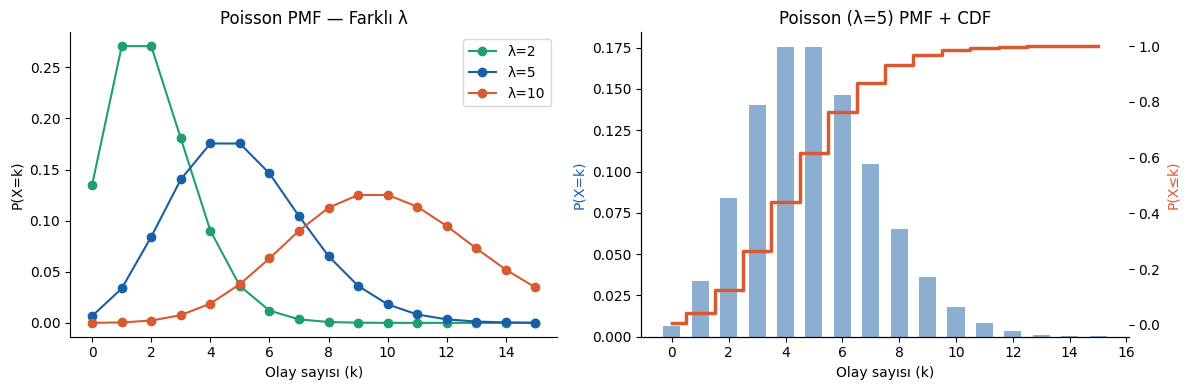

P(X=3)  = 0.1404  (tam 3 çağrı)
P(X≤5)  = 0.6160  (5 veya daha az)
P(X>10) = 0.0137  (10 dan fazla)


In [7]:
# Çağrı merkezi: λ=5 çağrı/saat
lam = 5
k = np.arange(0, 16)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Farklı lambda karşılaştırması
for l, renk in zip([2, 5, 10], ['#1D9E75', '#185FA5', '#D85A30']):
    axes[0].plot(k, poisson.pmf(k, l), 'o-', color=renk,
                 linewidth=1.5, markersize=6, label=f'λ={l}')
axes[0].set_xlabel('Olay sayısı (k)')
axes[0].set_ylabel('P(X=k)')
axes[0].set_title('Poisson PMF — Farklı λ')
axes[0].legend()

# λ=5 PMF + CDF
axes[1].bar(k, poisson.pmf(k, lam), color='#185FA5',
            alpha=0.5, width=0.6, label='PMF')
ax2 = axes[1].twinx()
ax2.step(k, poisson.cdf(k, lam), where='mid',
         color='#D85A30', linewidth=2.5, label='CDF')
ax2.set_ylabel('P(X≤k)', color='#D85A30')
axes[1].set_xlabel('Olay sayısı (k)')
axes[1].set_ylabel('P(X=k)', color='#185FA5')
axes[1].set_title('Poisson (λ=5) PMF + CDF')

plt.tight_layout()
plt.show()

print(f'P(X=3)  = {poisson.pmf(3, lam):.4f}  (tam 3 çağrı)')
print(f'P(X≤5)  = {poisson.cdf(5, lam):.4f}  (5 veya daha az)')
print(f'P(X>10) = {1-poisson.cdf(10, lam):.4f}  (10 dan fazla)')

## 7. Normal Dağılım & Z-Skoru

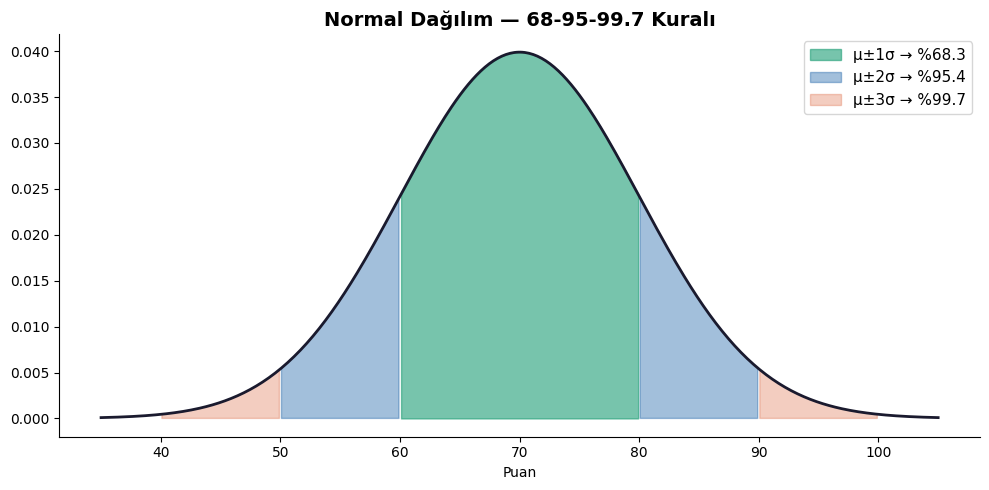

Z-Skoru Örnekleri:
  Ali (90 puan)   : Z = 2.00
  Zeynep (60 puan): Z = -1.00
  Ayşe (75 puan)  : Z = 0.50

P(X ≤ 80) = 0.841
P(60 ≤ X ≤ 80) = 0.683


In [8]:
mu, sigma = 70, 10
x = np.linspace(35, 105, 400)
y = norm.pdf(x, mu, sigma)

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(x, y, where=(x>=mu-sigma)&(x<=mu+sigma),
                color='#1D9E75', alpha=0.6, label='μ±1σ → %68.3')
ax.fill_between(x, y, where=((x>=mu-2*sigma)&(x<mu-sigma))|
                             ((x>mu+sigma)&(x<=mu+2*sigma)),
                color='#185FA5', alpha=0.4, label='μ±2σ → %95.4')
ax.fill_between(x, y, where=((x>=mu-3*sigma)&(x<mu-2*sigma))|
                             ((x>mu+2*sigma)&(x<=mu+3*sigma)),
                color='#D85A30', alpha=0.3, label='μ±3σ → %99.7')
ax.plot(x, y, color='#1a1a2e', linewidth=2)
ax.legend(fontsize=11)
ax.set_title('Normal Dağılım — 68-95-99.7 Kuralı', fontsize=14, fontweight='bold')
ax.set_xlabel('Puan')
plt.tight_layout()
plt.show()

# Z-skoru hesaplama
def z_skoru(x, mu, sigma):
    return (x - mu) / sigma

print('Z-Skoru Örnekleri:')
print(f'  Ali (90 puan)   : Z = {z_skoru(90, mu, sigma):.2f}')
print(f'  Zeynep (60 puan): Z = {z_skoru(60, mu, sigma):.2f}')
print(f'  Ayşe (75 puan)  : Z = {z_skoru(75, mu, sigma):.2f}')
print(f'\nP(X ≤ 80) = {norm.cdf(80, mu, sigma):.3f}')
print(f'P(60 ≤ X ≤ 80) = {norm.cdf(80,mu,sigma)-norm.cdf(60,mu,sigma):.3f}')

## 8. Uniform Dağılım

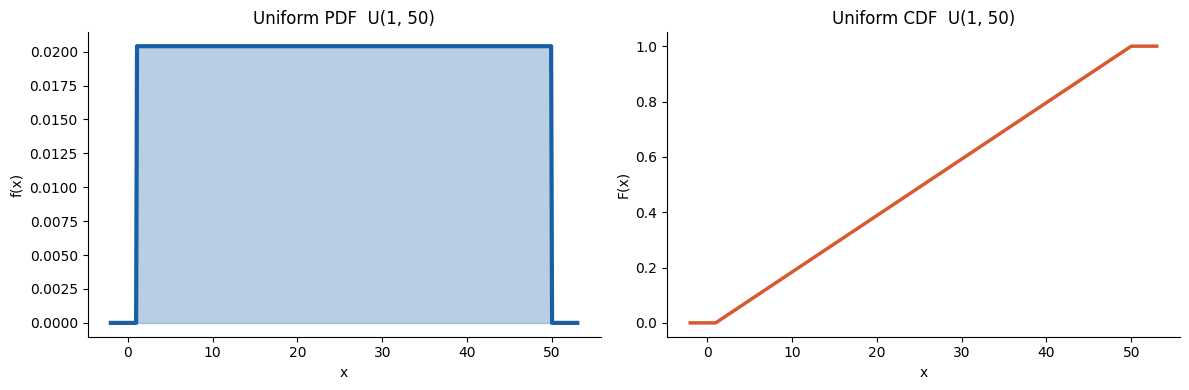

P(X ≤ 25) = 0.490
P(10 ≤ X ≤ 30) = 0.408


In [9]:
a, b = 1, 50
dist_u = uniform(loc=a, scale=b-a)

x = np.linspace(-2, 53, 500)
y_pdf = dist_u.pdf(x)
y_cdf = dist_u.cdf(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].fill_between(x, y_pdf, where=(x>=a)&(x<=b),
                     color='#185FA5', alpha=0.3)
axes[0].plot(x, y_pdf, color='#185FA5', linewidth=3)
axes[0].set_title('Uniform PDF  U(1, 50)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')

axes[1].plot(x, y_cdf, color='#D85A30', linewidth=2.5)
axes[1].set_title('Uniform CDF  U(1, 50)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('F(x)')

plt.tight_layout()
plt.show()

print(f'P(X ≤ 25) = {dist_u.cdf(25):.3f}')
print(f'P(10 ≤ X ≤ 30) = {dist_u.cdf(30)-dist_u.cdf(10):.3f}')

## 9. Log-Normal Dağılım

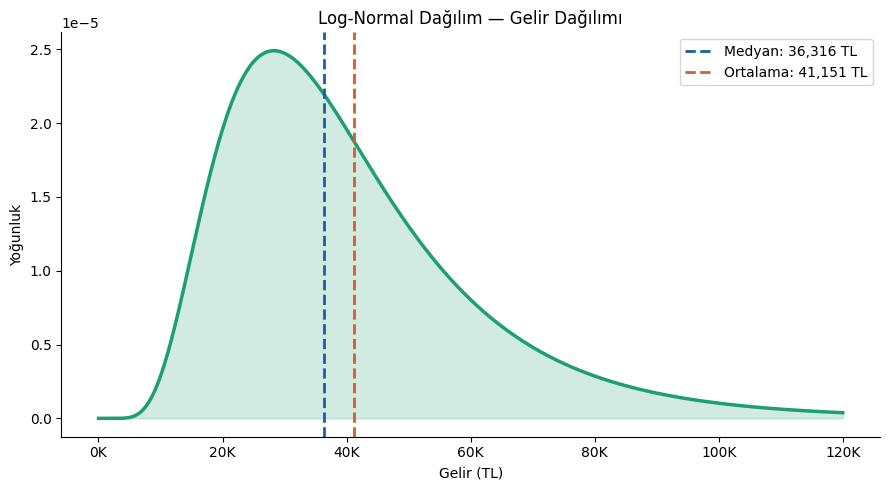

Medyan   : 36,316 TL
Ortalama : 41,151 TL
Ortalama > Medyan → sağa çarpık (right-skewed)
P(X ≤ 50000) = 0.739


In [10]:
mu_ln, sigma_ln = 10.5, 0.5
dist_ln = lognorm(s=sigma_ln, scale=np.exp(mu_ln))

x = np.linspace(0, 120000, 1000)
y = dist_ln.pdf(x)

plt.fill_between(x, y, color='#1D9E75', alpha=0.2)
plt.plot(x, y, color='#1D9E75', linewidth=2.5)
plt.axvline(dist_ln.median(), color='#185FA5', linestyle='--',
            linewidth=2, label=f'Medyan: {dist_ln.median():,.0f} TL')
plt.axvline(dist_ln.mean(), color='#D85A30', linestyle='--',
            linewidth=2, label=f'Ortalama: {dist_ln.mean():,.0f} TL')
plt.xlabel('Gelir (TL)')
plt.ylabel('Yoğunluk')
plt.title('Log-Normal Dağılım — Gelir Dağılımı')
plt.legend()
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{int(v/1000)}K'))
plt.tight_layout()
plt.show()

print(f'Medyan   : {dist_ln.median():,.0f} TL')
print(f'Ortalama : {dist_ln.mean():,.0f} TL')
print(f'Ortalama > Medyan → sağa çarpık (right-skewed)')
print(f'P(X ≤ 50000) = {dist_ln.cdf(50000):.3f}')

## 10. Pareto Dağılımı

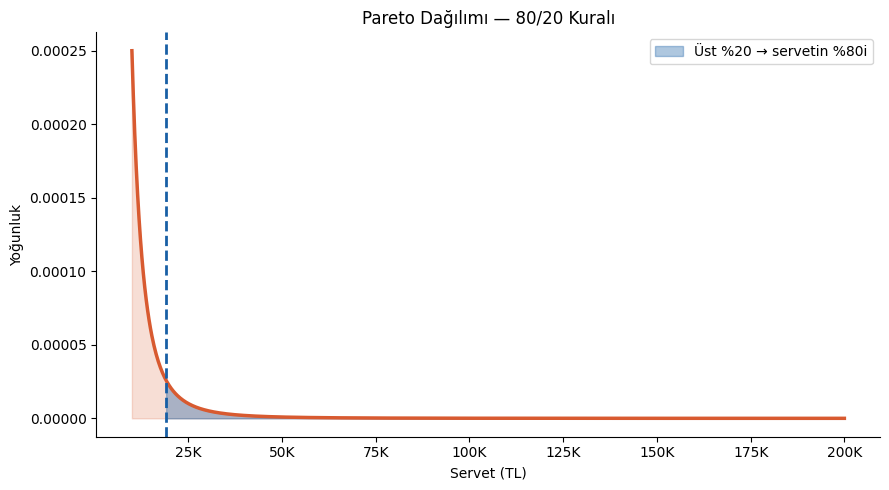

%80 sınırı        : 19,037 TL
P(X > 500.000)    : 0.0001
P(X > 1.000.000)  : 0.0000


In [11]:
alpha_p, xm = 2.5, 10000
dist_p = pareto(b=alpha_p, scale=xm)

x = np.linspace(xm, 200000, 1000)
y = dist_p.pdf(x)

p80 = dist_p.ppf(0.80)
plt.fill_between(x, y, color='#D85A30', alpha=0.2)
plt.fill_between(x, y, where=(x >= p80),
                 color='#185FA5', alpha=0.35,
                 label=f'Üst %20 → servetin %80i')
plt.plot(x, y, color='#D85A30', linewidth=2.5)
plt.axvline(p80, color='#185FA5', linestyle='--', linewidth=2)
plt.xlabel('Servet (TL)')
plt.ylabel('Yoğunluk')
plt.title('Pareto Dağılımı — 80/20 Kuralı')
plt.legend()
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda v, _: f'{int(v/1000)}K'))
plt.tight_layout()
plt.show()

print(f'%80 sınırı        : {p80:,.0f} TL')
print(f'P(X > 500.000)    : {1-dist_p.cdf(500000):.4f}')
print(f'P(X > 1.000.000)  : {1-dist_p.cdf(1000000):.4f}')